<a href="https://colab.research.google.com/github/samteccmrj/iiiced2025/blob/main/iii_ced_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# BLOCO 1 — Carregar dataset
# ==========================================

import pandas as pd

# carregar dataset
df = pd.read_excel("III_ced_pre_teste.xlsx")

print("================================================")
print("DIMENSÃO DO DATASET")
print("================================================")
print(df.shape)

print("\n================================================")
print("COLUNAS DO DATASET")
print("================================================")

for i, col in enumerate(df.columns):
    print(i, col)

print("\n================================================")
print("VALORES AUSENTES")
print("================================================")
print(df.isna().sum())

print("\n================================================")
print("AMOSTRA DOS DADOS")
print("================================================")
print(df.head())

DIMENSÃO DO DATASET
(122, 12)

COLUNAS DO DATASET
0 Carimbo de data/hora
1 Nome Completo  
2 Disciplina que leciona (principal)
3 Ano Escolar (principal)
4 1. Consigo explicar, em linhas gerais, a evolução da Inteligência Artificial até suas aplicações atuais na Educação.
5 2. Identifico exemplos práticos de como a IA pode apoiar o processo de ensino-aprendizagem.
6 3. Sei apontar riscos éticos relevantes no uso de IA na Educação, como viés, privacidade e autoria.
7 4. Tenho clareza sobre como orientar meus alunos para o uso responsável da IA em atividades escolares.
8 5. Sei estruturar prompts que aumentam a qualidade e a utilidade das respostas de uma ferramenta de IA.  
9 6. Sou capaz de ajustar um prompt de acordo com o resultado obtido, refinando minhas solicitações.
10 7. Consigo identificar atividades da minha disciplina que podem ser enriquecidas com o uso de IA generativa.
11 8. Sei utilizar ferramentas de IA generativa para personalizar materiais educacionais conforme o perfi

In [ ]:
# ==========================================
# BLOCO 2 — Selecionar variáveis para clusterização
# ==========================================

# selecionar somente as perguntas do pré-teste
colunas_likert = df.columns[4:12]

X = df[colunas_likert].copy()

print("================================================")
print("VARIÁVEIS UTILIZADAS NA CLUSTERIZAÇÃO")
print("================================================")

for col in colunas_likert:
    print(col)

print("\n================================================")
print("DIMENSÃO DA MATRIZ DE DADOS")
print("================================================")
print(X.shape)

print("\n================================================")
print("ESTATÍSTICAS DESCRITIVAS")
print("================================================")
print(X.describe())

print("\n================================================")
print("AMOSTRA DAS RESPOSTAS")
print("================================================")
print(X.head())

VARIÁVEIS UTILIZADAS NA CLUSTERIZAÇÃO
1. Consigo explicar, em linhas gerais, a evolução da Inteligência Artificial até suas aplicações atuais na Educação.
2. Identifico exemplos práticos de como a IA pode apoiar o processo de ensino-aprendizagem.
3. Sei apontar riscos éticos relevantes no uso de IA na Educação, como viés, privacidade e autoria.
4. Tenho clareza sobre como orientar meus alunos para o uso responsável da IA em atividades escolares.
5. Sei estruturar prompts que aumentam a qualidade e a utilidade das respostas de uma ferramenta de IA.  
6. Sou capaz de ajustar um prompt de acordo com o resultado obtido, refinando minhas solicitações.
7. Consigo identificar atividades da minha disciplina que podem ser enriquecidas com o uso de IA generativa.
8. Sei utilizar ferramentas de IA generativa para personalizar materiais educacionais conforme o perfil dos estudantes.

DIMENSÃO DA MATRIZ DE DADOS
(122, 8)

ESTATÍSTICAS DESCRITIVAS
       1. Consigo explicar, em linhas gerais, a evol

RESULTADOS
k=2  |  inertia=543.93  |  silhouette=0.367
k=3  |  inertia=435.22  |  silhouette=0.253
k=4  |  inertia=384.50  |  silhouette=0.233
k=5  |  inertia=344.78  |  silhouette=0.204
k=6  |  inertia=315.64  |  silhouette=0.202
k=7  |  inertia=296.79  |  silhouette=0.210
k=8  |  inertia=280.85  |  silhouette=0.190
k=9  |  inertia=262.31  |  silhouette=0.199
k=10  |  inertia=253.49  |  silhouette=0.186


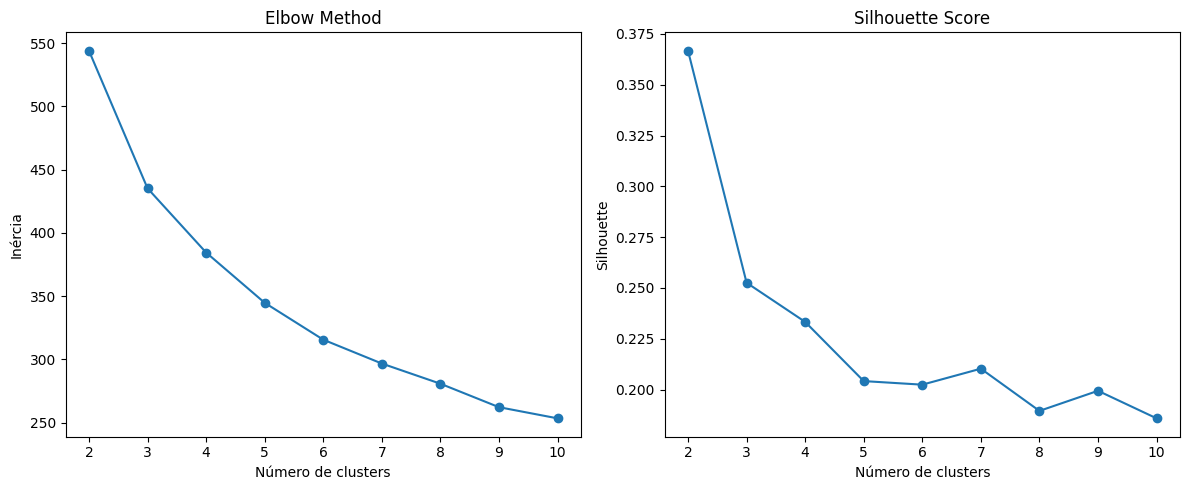

In [ ]:
# ==========================================
# BLOCO 3 — Elbow Method + Silhouette Score
# ==========================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# normalização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
silhouette_scores = []

k_range = range(2, 11)

for k in k_range:

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

print("====================================")
print("RESULTADOS")
print("====================================")

for k, iner, sil in zip(k_range, inertia, silhouette_scores):
    print(f"k={k}  |  inertia={iner:.2f}  |  silhouette={sil:.3f}")

# gráfico
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Número de clusters")
plt.ylabel("Inércia")

plt.subplot(1,2,2)
plt.plot(k_range, silhouette_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# BLOCO 4 — Clusterização final (k = 3)
# ==========================================

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

print("====================================")
print("DISTRIBUIÇÃO DOS CLUSTERS")
print("====================================")

print(df["cluster"].value_counts())

DISTRIBUIÇÃO DOS CLUSTERS
cluster
1    51
0    36
2    35
Name: count, dtype: int64


In [ ]:
# ==========================================
# BLOCO 5 — Perfil médio dos clusters
# ==========================================

perfil_clusters = df.groupby("cluster")[colunas_likert].mean()

print("====================================")
print("PERFIL MÉDIO DOS CLUSTERS")
print("====================================")

print(perfil_clusters.round(2))

print("\n====================================")
print("QUANTIDADE POR CLUSTER")
print("====================================")

print(df["cluster"].value_counts())

PERFIL MÉDIO DOS CLUSTERS
         1. Consigo explicar, em linhas gerais, a evolução da Inteligência Artificial até suas aplicações atuais na Educação.  \
cluster                                                                                                                         
0                                                     1.67                                                                      
1                                                     2.90                                                                      
2                                                     3.77                                                                      

         2. Identifico exemplos práticos de como a IA pode apoiar o processo de ensino-aprendizagem.  \
cluster                                                                                                
0                                                     2.25                                             
1               

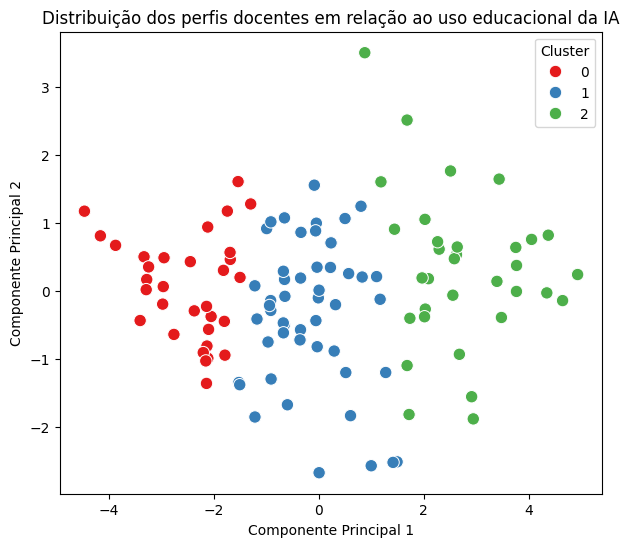

In [ ]:
# ==========================================
# BLOCO 6 — PCA para visualização dos clusters
# ==========================================

from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["pca1"] = X_pca[:,0]
df["pca2"] = X_pca[:,1]

plt.figure(figsize=(7,6))

sns.scatterplot(
    x="pca1",
    y="pca2",
    hue="cluster",
    palette="Set1",
    data=df,
    s=80
)

plt.title("Distribuição dos perfis docentes em relação ao uso educacional da IA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.legend(title="Cluster")

plt.show()

In [ ]:
# ==========================================
# BLOCO 7 — Tabela Disciplina × Cluster
# ==========================================

tabela_disciplina_cluster = pd.crosstab(
    df["Disciplina que leciona (principal)"],
    df["cluster"]
)

print("====================================")
print("DISCIPLINA x CLUSTER")
print("====================================")

print(tabela_disciplina_cluster)

DISCIPLINA x CLUSTER
cluster                             0   1  2
Disciplina que leciona (principal)          
Arte                                2   1  1
Biologia                            3   2  0
Ciências Naturais                   2   5  1
Filosofia                           0   1  2
Física                              2   2  2
Geografia                           2   4  3
História                            6   6  2
Língua Estrangeira Moderna          4   3  9
Língua Portuguesa                   4  10  4
Matemática                          8   5  6
Outros                              1   7  2
Química                             0   4  3
SEF                                 1   0  0
Sociologia                          1   1  0


In [ ]:
# ==========================================
# BLOCO 7A — Padronizar nome da disciplina
# ==========================================

df["Disciplina que leciona (principal)"] = df["Disciplina que leciona (principal)"].replace(
    {"SEF": "Educação Física"}
)

print("Disciplinas únicas no dataset:")
print(sorted(df["Disciplina que leciona (principal)"].unique()))

Disciplinas únicas no dataset:
['Arte', 'Biologia', 'Ciências Naturais', 'Educação Física', 'Filosofia', 'Física', 'Geografia', 'História', 'Língua Estrangeira Moderna', 'Língua Portuguesa', 'Matemática', 'Outros', 'Química', 'Sociologia']


In [ ]:
# ==========================================
# BLOCO 7B — Ajustar nomes dos perfis (quebra de linha)
# ==========================================

df["perfil_ia"] = df["cluster"].map({
    0: "Aproximação Inicial\ncom IA",
    1: "Experimentação Pedagógica\ncom IA",
    2: "Integração Pedagógica\nda IA"
})

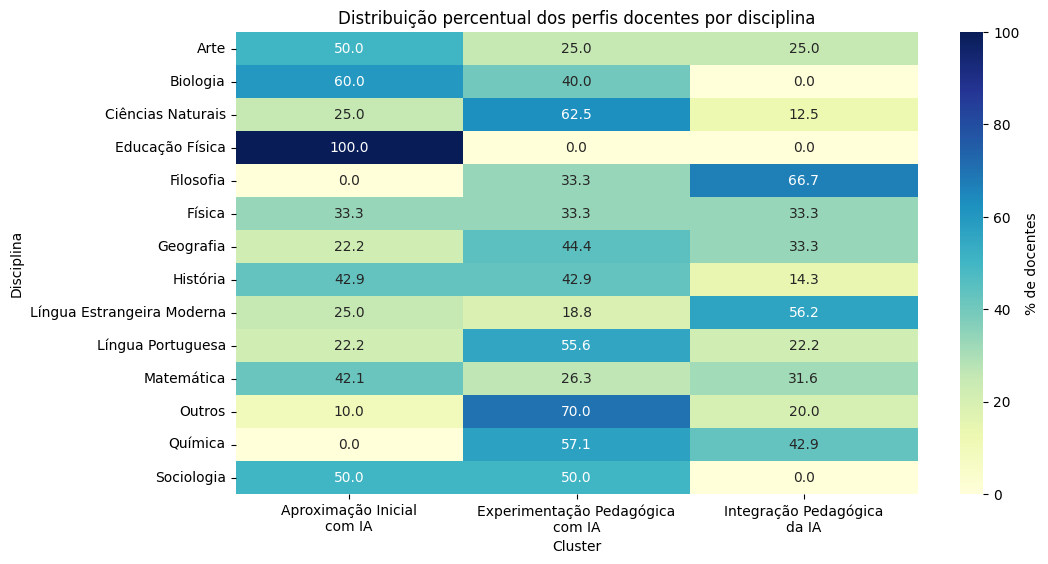

In [ ]:
# ==========================================
# BLOCO 8 — Heatmap Disciplina × Cluster (%)
# ==========================================

# tabela absoluta
tabela_disciplina_cluster = pd.crosstab(
    df["Disciplina que leciona (principal)"],
    df["perfil_ia"]
)

# converter para porcentagem por disciplina
tabela_percentual = tabela_disciplina_cluster.div(
    tabela_disciplina_cluster.sum(axis=1), axis=0
) * 100

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(11,6))

sns.heatmap(
    tabela_percentual,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={'label': '% de docentes'}
)

plt.title("Distribuição percentual dos perfis docentes por disciplina")
plt.xlabel("Cluster")
plt.ylabel("Disciplina")

plt.show()